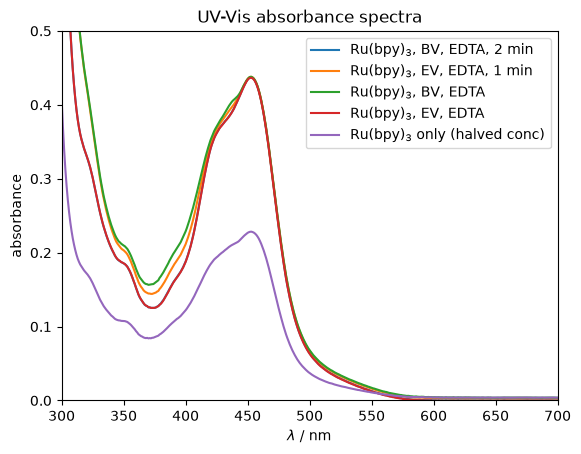

In [1]:
from lsmr_photocatalysis import DATA_DIR
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data = DATA_DIR/'yhn24_Abs_Jun26 23 June 2026 15_03 GMT Daylight Time'

# plotting the UV-Vis absorbance spectra from the .csv files in the results folder

labels = ['Ru(bpy)$_3$, BV, EDTA, 2 min',
          'Ru(bpy)$_3$, EV, EDTA, 1 min',
          'Ru(bpy)$_3$, BV, EDTA',
          'Ru(bpy)$_3$, EV, EDTA',
          'Ru(bpy)$_3$ only (halved conc)']

i = 0
for f in Path(data).glob('*Sample.Raw.csv'):
    if f.name == 'Irradiated1min_Rubpy_BV_EDTA.Sample.Raw.csv': # ignore this one
        continue
    else:
        df = pd.read_csv(f)  
        plt.plot(df.iloc[:, 0], df.iloc[:, 1], label=labels[i])
        i += 1

plt.xlim(300, 700)
plt.ylim(0, 0.5)
plt.xlabel(r'$\lambda$ / nm')
plt.ylabel(r'absorbance')
plt.title('UV-Vis absorbance spectra')
plt.legend()
plt.show()

In [2]:
# find the extinction coefficient for the Ru(bpy)3 only sample in 1 cm cuvette
c = (17.3e-3/748.62/25e-3)*50e-6/3e-3 # concentration of Ru(bpy)3 in 3 mL cuvette
df = pd.read_csv(data/'Rubpy_50uLin3mL.Sample.Raw.csv')
lamdamax, Amax = df.loc[df[(df.iloc[:,0] >=350)].iloc[:,1].idxmax()]
e = Amax/(c*1e-2)
print(f'Ru(bpy)3: λmax = {lamdamax} nm, Amax = {Amax:.3f}, ε = {e:.3e} L mol-1 m-1')

Ru(bpy)3: λmax = 453.0 nm, Amax = 0.228, ε = 1.482e+06 L mol-1 m-1


In [3]:
# find the concentration for 1% transmittance (i.e. A = 2) for Ru(bpy)3 in l = 700 μm chamber
c = 2/(e*700e-6)
print(f'Ru(bpy)3: c = {c:.3e} M for 1% transmittance in l = 700 μm chamber')

Ru(bpy)3: c = 1.927e-03 M for 1% transmittance in l = 700 μm chamber
